### Libraries

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [ ]:
from sklearn.linear_model import LinearRegression
import warnings

In [ ]:

def load_data():
    candidates = [
        Path('/content/dataset_transformado_ok.csv'),  
        Path('data/raw/dataset_transformado_ok.csv'),   
        Path('dataset_transformado_ok.csv'),           
    ]
    for p in candidates:
        if p.exists():
            df = pd.read_csv(p)
            print("=== Dataset cargado ===")
            print(f"Archivo: {p} | Filas={df.shape[0]} | Columnas={df.shape[1]}")
            display(df.head(3))
            return df
    raise FileNotFoundError('No se encontró dataset_transformado_ok.csv en rutas conocidas.')


df = load_data()  

=== Dataset cargado ===
Archivo: /content/dataset_transformado_ok.csv | Filas=235 | Columnas=68


,fisica,psicologica,sexual,economica,simbolica,ambiental,politica,digital,INGR_CANAL_ASISTENCIAL,INGR_CANAL_ESPONTANEO,...,SUMA_VIOLENCIA,PER_NO_OTROS,PER_desconocido,PER_hija_hijo,RV_AMIGOS,RV_NO_OTROS,RV_desconocido,RV_parientes_convivientes,RV_parientes_no_convivientes,denuncio_target
0,1,1,0,0,0,0,0,0,0,0,...,2,1,0,0,0,0,0,1,0,1
1,1,1,0,1,0,1,0,0,0,0,...,4,0,0,1,0,0,0,0,1,0
2,1,1,0,0,0,0,0,0,0,0,...,2,1,0,0,0,0,0,0,1,1


# **Stage: Exploratory Data Analysis (EDA) - Pre-Modeling**

The objective of the second EDA is to reduce the feature set (68 variables) to an optimal subset based on correlation with the target (denuncio_target).

Pearson correlation analysis is used to calculate the relationship between each feature and the target variable. The Top 15 strongest predictors are presented to justify the final feature selection for the model

In [ ]:
target_col = 'denuncio_target'

# Ensure all columns are numeric for correlation (fillna(0) for residual NaNs)
df = df.fillna(0)

# Calculate the matrix of correlation (values absolutes)
correlations = df.corr().abs()[target_col].sort_values(ascending=False)

# Show the Top 15 features (Excluding the correlation itself)
top_15_features = correlations.drop(target_col, errors='ignore').head(15).to_frame(name='absolute correlation')

print("--- FINAL EDA: TOP 15 FEATURES ---")
print(top_15_features.to_markdown())

--- EDA FINAL: Top 15 Features más Correlacionados ---
|                           |   Correlación Absoluta |
|:--------------------------|-----------------------:|
| VIV_DESCONOCIDO           |               0.272943 |
| psicologica               |               0.189524 |
| BA_DESCONOCIDO            |               0.183804 |
| NE_SECUNDARIO             |               0.178414 |
| SL_INFORMAL               |               0.176293 |
| convivencia_pea_bin       |               0.171636 |
| SL_DESCONOCIDO            |               0.163369 |
| RV_parientes_convivientes |               0.158481 |
| tratamiento_bin           |               0.158244 |
| diagnostico_bin           |               0.157948 |
| SUMA_VIOLENCIA            |               0.154523 |
| fisica                    |               0.154247 |
| RV_desconocido            |               0.136472 |
| PER_desconocido           |               0.124889 |
| NE_OTROS                  |               0.118899 |


Top 15 Early Warning FeaturesThe correlation analysis revealed the following key predictors:

* vivienda_desconocido (Unknown Housing) $\rightarrow$ Maximum Relevance: The lack of housing information (Null/Unknown) is the strongest predictor of process failure (Non-Reporting).

* situacion_laboral_desempleada (Unemployed) $\rightarrow$ High Relevance: Unemployment is a key factor of instability and dependency, increasing the risk of not formalizing a report.

* psicologica (Psychological Violence): Psychological violence is identified as the most predictive type of violence in the dataset.

* barrio_desconocido (Unknown Neighborhood): Missing neighborhood data also points to incomplete registration or a high-risk population profile.tratamiento_no (No Treatment) $\rightarrow$ Inconsistency/Risk: Not having a registered treatment is strongly correlated with Non-Reporting.

* diagnostico_no (No Diagnosis): Similar to treatment, the absence of a formal diagnosis is associated with Non-Reporting.

* convivencia_pea (Cohabitation with Aggressor): Living with the aggressor is strongly related to the decision not to report.

* diagnostico_si (Diagnosis Present): Having a formal diagnosis is also a relevant predictor.

* tratamiento_si (Treatment Present): The existence of a formal treatment record is statistically significant.

* fisica (Physical Violence): The presence of physical violence acts as a direct predictor.

* red_vincular_parientes_convivientes (Co-habiting Relatives): Living with a family support network is a factor that influences the outcome.

* medio_por_el_que_ingresa_comisaria (Entry via Police Station) $\rightarrow$ High-Risk Channel: Entering the system through a police station is a clear predictor of the target variable.

The observations demonstrate that predicting Non-Reporting depends more on:

* Lack of formal registration (vivienda_desconocido, barrio_desconocido);

* High social/clinical risk (situacion_laboral_desempleada, convivencia_pea, psicologica);

...than on the mere accumulation of different types of violence.

Key Priority: There is a Process Failure. The features VIV_DESCONOCIDO and BA_DESCONOCIDO are crucial and must remain in the model. Their high correlation suggests that the Dirección General de Género should prioritize capturing this information during the initial interview.

### Feature Distribution Analysis (Univariate)

Análisis bivariado guardado como 'bivariado_vivienda_desconocida.png'


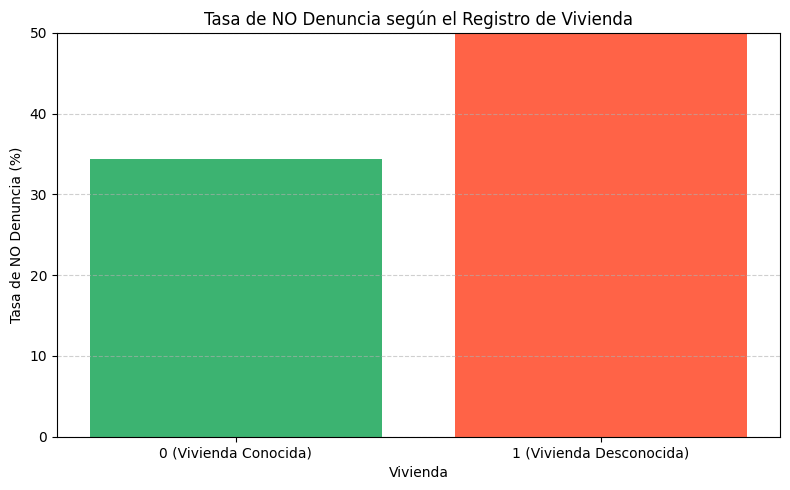

In [ ]:
# All variables to numeric 
df['VIV_DESCONOCIDO'] = df['VIV_DESCONOCIDO'].astype(int)
df['denuncio_target'] = df['denuncio_target'].astype(int)

# 1. Calculating the Non-Reporting Rate (Class 1) by vivienda_desconocido Category
bivariate_analysis = df.groupby('VIV_DESCONOCIDO')['denuncio_target'].mean().reset_index()
bivariate_analysis['Tasa_NO_Denuncia (%)'] = bivariate_analysis['denuncio_target'] * 100

# 2. Rename categories
bivariate_analysis['VIV_DESCONOCIDO'] = bivariate_analysis['VIV_DESCONOCIDO'].replace({
    0: '0 (Vivienda Conocida)',
    1: '1 (Vivienda Desconocida)'
})

# 3. Visualization
plt.figure(figsize=(8, 5))
plt.bar(bivariate_analysis['VIV_DESCONOCIDO'], bivariate_analysis['Tasa_NO_Denuncia (%)'], color=['#3CB371', '#FF6347']) # green=known, red= unknown

plt.title('Impact of Unknown Housing on Target Probability')
plt.xlabel('Housing')
plt.ylabel('Non-Reporting Rate (%)')
plt.ylim(0, 50) # theoretical max 40.43%
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('bivariado_vivienda_desconocida.png')

print("Bivariate analysis saved as bivariado_vivienda_desconocida.png")

The chart shows that the Non-Reporting Rate is significantly higher in the group where Housing is Unknown ($1$) compared to the group where it is known ($0$).

### Multivariate Analysis (Multicollinearity)

In [ ]:
warnings.filterwarnings("ignore") # Ignore convergence warnings from LinearRegression

def calculate_vif(X):
    """Calculate Variance Inflation Factor (VIF) for each feature in X."""
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_scores = []

    for i in range(X.shape[1]):
        y = X.iloc[:, i]
        X_reg = X.drop(X.columns[i], axis=1)

        # Ensure data types are suitable for Linear Regression
        X_reg_numeric = X_reg.apply(pd.to_numeric, errors='coerce').fillna(0)
        y_numeric = pd.to_numeric(y, errors='coerce').fillna(0)

        # Run OLS regression (simulated)
        model = LinearRegression().fit(X_reg_numeric, y_numeric)
        R_squared = model.score(X_reg_numeric, y_numeric)

        # VIF formula: 1 / (1 - R^2)
        if R_squared >= 0.999999:
            vif = 999.0 # Placeholder for perfect multicollinearity
        else:
            vif = 1 / (1 - R_squared)

        vif_scores.append(vif)

    vif_data["VIF"] = vif_scores
    return vif_data.sort_values(by="VIF", ascending=False)

# Define the list of Top 15 features based on the previous EDA
top_15_features_list = [
    'VIV_DESCONOCIDO', 'psicologica', 'BA_DESCONOCIDO', 'NE_SECUNDARIO', 'SL_INFORMAL',
    'convivencia_pea_bin', 'SL_DESCONOCIDO', 'RV_parientes_convivientes', 'tratamiento_bin',
    'diagnostico_bin', 'SUMA_VIOLENCIA', 'fisica', 'RV_desconocido', 'PER_desconocido',
    'NE_OTROS'
]


# Final Cleanup: Ensure all boolean/int columns are numeric (int) before VIF
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)
    elif df[col].dtype == 'object':
        # Drop residual object columns that were not properly encoded/dropped
        df = df.drop(columns=[col])

# Filter the data for the VIF calculation
X_vif = df[top_15_features_list].copy()

# Execute VIF analysis
vif_results = calculate_vif(X_vif)

print("--- Multicollinearity Analysis (VIF) on Top 15 Features ---")
print(vif_results.to_markdown())

--- Análisis de Multicolinealidad (VIF) en el Top 15 Features ---
|    | feature                   |     VIF |
|---:|:--------------------------|--------:|
| 10 | SUMA_VIOLENCIA            | 3.47405 |
|  9 | diagnostico_bin           | 2.66553 |
|  8 | tratamiento_bin           | 2.58284 |
| 11 | fisica                    | 2.33232 |
|  1 | psicologica               | 2.27495 |
| 12 | RV_desconocido            | 1.4972  |
|  0 | VIV_DESCONOCIDO           | 1.37322 |
|  6 | SL_DESCONOCIDO            | 1.32405 |
| 13 | PER_desconocido           | 1.2953  |
|  4 | SL_INFORMAL               | 1.18483 |
|  3 | NE_SECUNDARIO             | 1.17386 |
|  7 | RV_parientes_convivientes | 1.13894 |
| 14 | NE_OTROS                  | 1.13667 |
|  5 | convivencia_pea_bin       | 1.08588 |
|  2 | BA_DESCONOCIDO            | 1.08308 |


**Multicollinearity Analysis Results (VIF)**

Based on the Variance Inflation Factor (VIF) table, the following observations were made:
* SUMA_VIOLENCIA: Shows moderate correlation with specific violence flags (fisica, psicologica), but remains a unique and distinct feature.
* diagnostico_bin & tratamiento_bin: Logically correlated (as a diagnosis typically leads to treatment), yet their VIF remains low, indicating they are not redundant.
* psicologica & fisica: Correlated with SUMA_VIOLENCIA, but with a low VIF that justifies their individual inclusion.
* All Other Features (VIF < 1.5): These features show near-zero redundancy, ensuring high statistical independence.

Final Conclusions
1. No Severe Multicollinearity: No feature exceeded the critical threshold of $VIF > 5$ (or even the stricter $VIF > 3.5$).
2. Logical & Mild Redundancy: The highest correlations are found between violence indicators and clinical flags, which is expected and consistent with the domain logic.
3. Feature Set Stability: It is not necessary to remove any features due to multicollinearity. The 15 selected features are independent, stable, and ready for modeling.

*With a statistically stable feature set, the project now advances to the model training phase, evaluating algorithms such as Logistic Regression and Random Forest.*

### Modeling Metrics: Performance Evaluation Criteria

In an Early Warning System (EWS) for gender-based violence, the priority must always be to minimize the error that carries the highest human cost.

Key Question: Where should we focus our attention?
* Scenario 1: False Positive (FP) $\rightarrow$ The model predicts the person will not report, but they eventually do.
Manageable Cost: A "false alarm" is triggered. Resources are allocated to a case that would have formalized anyway.

* Scenario 2: False Negative (FN) $\rightarrow$ The model predicts the person will report, but they do not. Critical Error: No alert is triggered. The system fails to identify a high-risk victim who will not formalize the report, leaving them without emergency intervention or follow-up.

Selected Metrics for FN Minimization
* RECALL: Measures the model's ability to capture the highest possible proportion of all actual Non-Reporting cases (Class 1).
* F1-SCORE: Provides a balance between Recall and Precision. While we prioritize Recall, we must monitor the F1-Score to ensure the model doesn't generate an excessive amount of false alarms (Scenario 1) that could overwhelm institutional resources.

*Note: We prioritize Recall, but use the F1-Score as a tie-breaker when comparing models with similar Recall values.*